# Portfolio Optimization of Major Tech Stocks

This notebook explores portfolio optimization for a selection of major tech stocks:

**AAPL, MSFT, GOOGL, AMZN, and META**

---

##  Main Objectives

### 1. Simulate and Visualize the Efficient Frontier

We used a `PortfolioOptimizer` class to:

- Fetch historical stock price data  
- Calculate daily returns  
- Simulate thousands of random portfolios  

This allowed us to:

- Plot the **Efficient Frontier**
- Identify the **Maximum Sharpe Ratio Portfolio** (best risk-adjusted return)
- Identify the **Minimum Volatility Portfolio** (lowest risk portfolio)

The Efficient Frontier highlights portfolios that offer the highest expected return for a given level of risk.

---

### 2. Analyze Dominant Stock Contributions

We enhanced the Efficient Frontier visualization by:

- Coloring each simulated portfolio based on its **dominant stock**
- Defining dominant stock as the stock with the highest portfolio weight

This provided insights into:

- Which stocks drive performance in different risk-return regions
- How asset concentration influences portfolio positioning

---

### 3. Calculate and Visualize Stock Return Correlations

To understand diversification:

- We computed the **correlation matrix** of daily returns
- Visualized it using a **heatmap**

This helped quantify:

- Linear relationships between stock movements
- The degree of co-movement among assets

---

### 4. Diversification and Rebalancing Insights

Based on the correlation analysis, we:

- Examined the impact of mostly high positive correlations
- Identified stocks with strong correlation influence
- Discussed strategies for adjusting portfolio weights

Key focus areas:

- Risk management
- Diversification efficiency
- Strategic rebalancing aligned with investment goals

---

##  Conclusion

This notebook provides a comprehensive framework for:

- Constructing a diversified portfolio  
- Applying modern portfolio theory  
- Understanding the interaction between risk, return, and correlation  

It demonstrates how quantitative methods can guide portfolio construction and management decisions in a multi-asset setting.

In [4]:
pip install yfinance

Note: you may need to restart the kernel to use updated packages.


[*********************100%***********************]  5 of 5 completed



Optimal Portfolio Weights:
Max Sharpe Ratio Portfolio:
  INFY.NS: 91.19%
  ADANIGREEN.NS: 0.70%
  TATAPOWER.NS: 2.18%
  SBIN.NS: 2.61%
  ULTRACEMCO.NS: 3.32%

Min Volatility Portfolio:
  INFY.NS: 7.36%
  ADANIGREEN.NS: 39.47%
  TATAPOWER.NS: 17.05%
  SBIN.NS: 1.74%
  ULTRACEMCO.NS: 34.39%


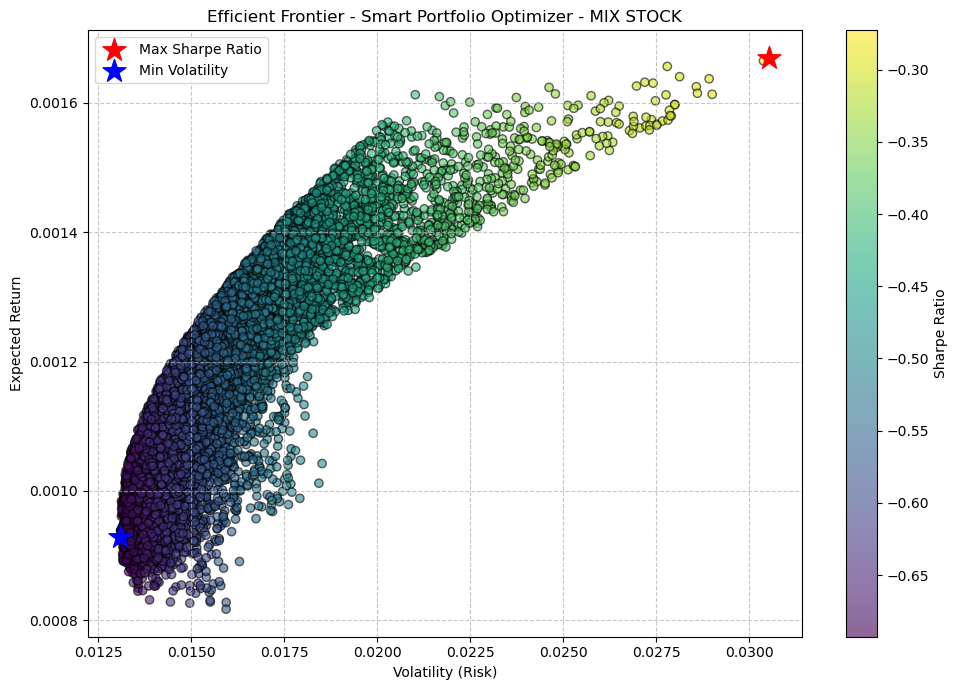

In [17]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# User configuration
TICKERS = ['INFY.NS', 'ADANIGREEN.NS', 'TATAPOWER.NS', 'SBIN.NS', 'ULTRACEMCO.NS']
START_DATE = '2020-01-01'
END_DATE = '2025-12-31'
RISK_FREE_RATE = 0.01
NUM_PORTFOLIOS = 10000

import pandas as pd
import numpy as np
import yfinance as yf

class PortfolioOptimizer:
    def __init__(self, tickers, start_date, end_date, risk_free_rate=0.01):
        self.tickers = tickers
        self.start_date = start_date
        self.end_date = end_date
        self.risk_free_rate = risk_free_rate
        self.data = self._fetch_data()
        self.returns = self._calculate_returns()
        self.expected_returns = self.returns.mean()
        self.cov_matrix = self.returns.cov()

    def _fetch_data(self):
        df = yf.download(self.tickers, start=self.start_date, end=self.end_date)
        # Try to get 'Adj Close' if available, else fallback to 'Close'
        if ('Adj Close' in df.columns.get_level_values(0)):
            price = df['Adj Close']
        else:
            price = df['Close']
        return price.dropna()

    def _calculate_returns(self):
        return self.data.pct_change().dropna()

    def simulate_portfolios(self, num_portfolios=10000):
        results = {
            'returns': [],
            'volatility': [],
            'sharpe': [],
            'weights': []
        }
        for _ in range(num_portfolios):
            weights = np.random.dirichlet(np.ones(len(self.tickers)), size=1)[0]
            port_return = np.dot(weights, self.expected_returns)
            port_volatility = np.sqrt(np.dot(weights.T, np.dot(self.cov_matrix, weights)))
            sharpe = (port_return - self.risk_free_rate) / port_volatility
            results['returns'].append(port_return)
            results['volatility'].append(port_volatility)
            results['sharpe'].append(sharpe)
            results['weights'].append(weights)
        return results

    def get_optimal_portfolios(self, results):
        max_sharpe_idx = np.argmax(results['sharpe'])
        min_vol_idx = np.argmin(results['volatility'])
        return {
            'max_sharpe': {
                'return': results['returns'][max_sharpe_idx],
                'volatility': results['volatility'][max_sharpe_idx],
                'sharpe': results['sharpe'][max_sharpe_idx],
                'weights': results['weights'][max_sharpe_idx]
            },
            'min_volatility': {
                'return': results['returns'][min_vol_idx],
                'volatility': results['volatility'][min_vol_idx],
                'sharpe': results['sharpe'][min_vol_idx],
                'weights': results['weights'][min_vol_idx]
            }
        }


# Initialize optimizer
optimizer = PortfolioOptimizer(TICKERS, START_DATE, END_DATE, RISK_FREE_RATE)
results = optimizer.simulate_portfolios(NUM_PORTFOLIOS)
optimal = optimizer.get_optimal_portfolios(results)

# Prepare data for plotting
returns = np.array(results['returns'])
volatility = np.array(results['volatility'])
sharpe = np.array(results['sharpe'])
weights = np.array(results['weights'])

# Plot Efficient Frontier
plt.figure(figsize=(10, 7))
scatter = plt.scatter(volatility, returns, c=sharpe, cmap='viridis', alpha=0.6, edgecolor='k')
plt.colorbar(scatter, label='Sharpe Ratio')

# Highlight optimal portfolios
plt.scatter(optimal['max_sharpe']['volatility'], optimal['max_sharpe']['return'],
            color='red', marker='*', s=300, label='Max Sharpe Ratio')
plt.scatter(optimal['min_volatility']['volatility'], optimal['min_volatility']['return'],
            color='blue', marker='*', s=300, label='Min Volatility')

plt.title('Efficient Frontier - Smart Portfolio Optimizer - MIX STOCK')
plt.xlabel('Volatility (Risk)')
plt.ylabel('Expected Return')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# Display optimal weights
print("\nOptimal Portfolio Weights:")
print("Max Sharpe Ratio Portfolio:")
for ticker, weight in zip(TICKERS, optimal['max_sharpe']['weights']):
    print(f"  {ticker}: {weight:.2%}")
print("\nMin Volatility Portfolio:")
for ticker, weight in zip(TICKERS, optimal['min_volatility']['weights']):
    print(f"  {ticker}: {weight:.2%}")

plt.show()

[*********************100%***********************]  5 of 5 completed



Optimal Portfolio Weights:
Max Sharpe Ratio Portfolio:
  INFY.NS: 91.02%
  ADANIGREEN.NS: 5.24%
  SUNPHARMA.NS: 3.28%
  SBIN.NS: 0.32%
  MARUTI.NS: 0.13%

Min Volatility Portfolio:
  INFY.NS: 6.17%
  ADANIGREEN.NS: 26.58%
  SUNPHARMA.NS: 18.78%
  SBIN.NS: 10.28%
  MARUTI.NS: 38.19%


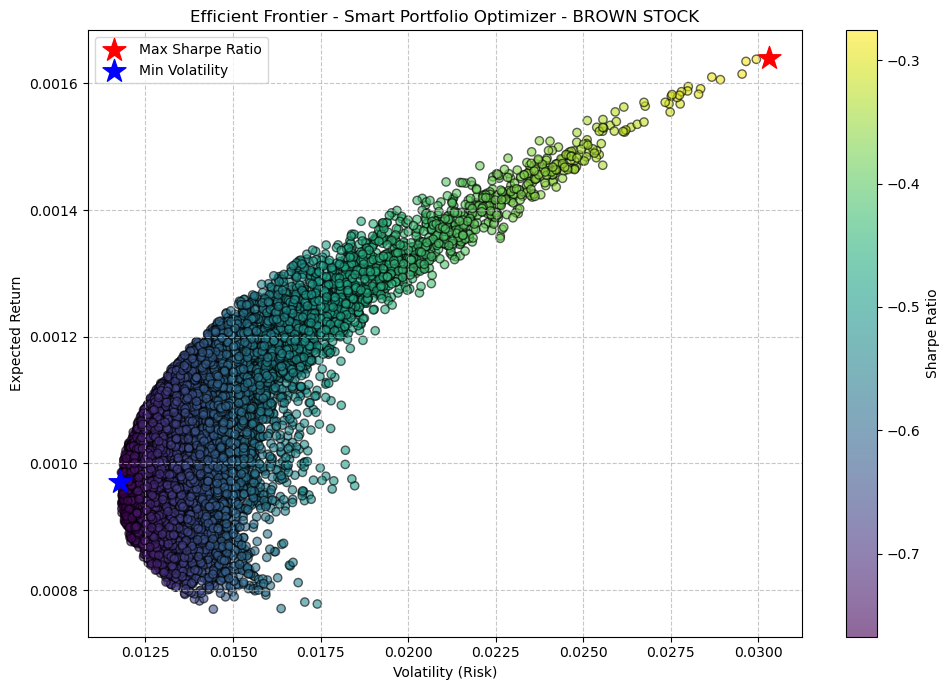

In [16]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# User configuration
TICKERS = ['INFY.NS', 'ADANIGREEN.NS', 'SUNPHARMA.NS', 'SBIN.NS', 'MARUTI.NS']
START_DATE = '2020-01-01'
END_DATE = '2025-12-31'
RISK_FREE_RATE = 0.01
NUM_PORTFOLIOS = 10000

import pandas as pd
import numpy as np
import yfinance as yf

class PortfolioOptimizer:
    def __init__(self, tickers, start_date, end_date, risk_free_rate=0.01):
        self.tickers = tickers
        self.start_date = start_date
        self.end_date = end_date
        self.risk_free_rate = risk_free_rate
        self.data = self._fetch_data()
        self.returns = self._calculate_returns()
        self.expected_returns = self.returns.mean()
        self.cov_matrix = self.returns.cov()

    def _fetch_data(self):
        df = yf.download(self.tickers, start=self.start_date, end=self.end_date)
        # Try to get 'Adj Close' if available, else fallback to 'Close'
        if ('Adj Close' in df.columns.get_level_values(0)):
            price = df['Adj Close']
        else:
            price = df['Close']
        return price.dropna()

    def _calculate_returns(self):
        return self.data.pct_change().dropna()

    def simulate_portfolios(self, num_portfolios=10000):
        results = {
            'returns': [],
            'volatility': [],
            'sharpe': [],
            'weights': []
        }
        for _ in range(num_portfolios):
            weights = np.random.dirichlet(np.ones(len(self.tickers)), size=1)[0]
            port_return = np.dot(weights, self.expected_returns)
            port_volatility = np.sqrt(np.dot(weights.T, np.dot(self.cov_matrix, weights)))
            sharpe = (port_return - self.risk_free_rate) / port_volatility
            results['returns'].append(port_return)
            results['volatility'].append(port_volatility)
            results['sharpe'].append(sharpe)
            results['weights'].append(weights)
        return results

    def get_optimal_portfolios(self, results):
        max_sharpe_idx = np.argmax(results['sharpe'])
        min_vol_idx = np.argmin(results['volatility'])
        return {
            'max_sharpe': {
                'return': results['returns'][max_sharpe_idx],
                'volatility': results['volatility'][max_sharpe_idx],
                'sharpe': results['sharpe'][max_sharpe_idx],
                'weights': results['weights'][max_sharpe_idx]
            },
            'min_volatility': {
                'return': results['returns'][min_vol_idx],
                'volatility': results['volatility'][min_vol_idx],
                'sharpe': results['sharpe'][min_vol_idx],
                'weights': results['weights'][min_vol_idx]
            }
        }


# Initialize optimizer
optimizer = PortfolioOptimizer(TICKERS, START_DATE, END_DATE, RISK_FREE_RATE)
results = optimizer.simulate_portfolios(NUM_PORTFOLIOS)
optimal = optimizer.get_optimal_portfolios(results)

# Prepare data for plotting
returns = np.array(results['returns'])
volatility = np.array(results['volatility'])
sharpe = np.array(results['sharpe'])
weights = np.array(results['weights'])

# Plot Efficient Frontier
plt.figure(figsize=(10, 7))
scatter = plt.scatter(volatility, returns, c=sharpe, cmap='viridis', alpha=0.6, edgecolor='k')
plt.colorbar(scatter, label='Sharpe Ratio')

# Highlight optimal portfolios
plt.scatter(optimal['max_sharpe']['volatility'], optimal['max_sharpe']['return'],
            color='red', marker='*', s=300, label='Max Sharpe Ratio')
plt.scatter(optimal['min_volatility']['volatility'], optimal['min_volatility']['return'],
            color='blue', marker='*', s=300, label='Min Volatility')

plt.title('Efficient Frontier - Smart Portfolio Optimizer - BROWN STOCK')
plt.xlabel('Volatility (Risk)')
plt.ylabel('Expected Return')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# Display optimal weights
print("\nOptimal Portfolio Weights:")
print("Max Sharpe Ratio Portfolio:")
for ticker, weight in zip(TICKERS, optimal['max_sharpe']['weights']):
    print(f"  {ticker}: {weight:.2%}")
print("\nMin Volatility Portfolio:")
for ticker, weight in zip(TICKERS, optimal['min_volatility']['weights']):
    print(f"  {ticker}: {weight:.2%}")

plt.show()

[*********************100%***********************]  5 of 5 completed



Optimal Portfolio Weights:
Max Sharpe Ratio Portfolio:
  TATAPOWER.NS: 0.53%
  ADANIGREEN.NS: 0.84%
  JSWENERGY.NS: 5.05%
  SUZLON.NS: 92.53%
  NTPC.NS: 1.04%

Min Volatility Portfolio:
  TATAPOWER.NS: 10.21%
  ADANIGREEN.NS: 8.96%
  JSWENERGY.NS: 58.95%
  SUZLON.NS: 11.54%
  NTPC.NS: 10.34%


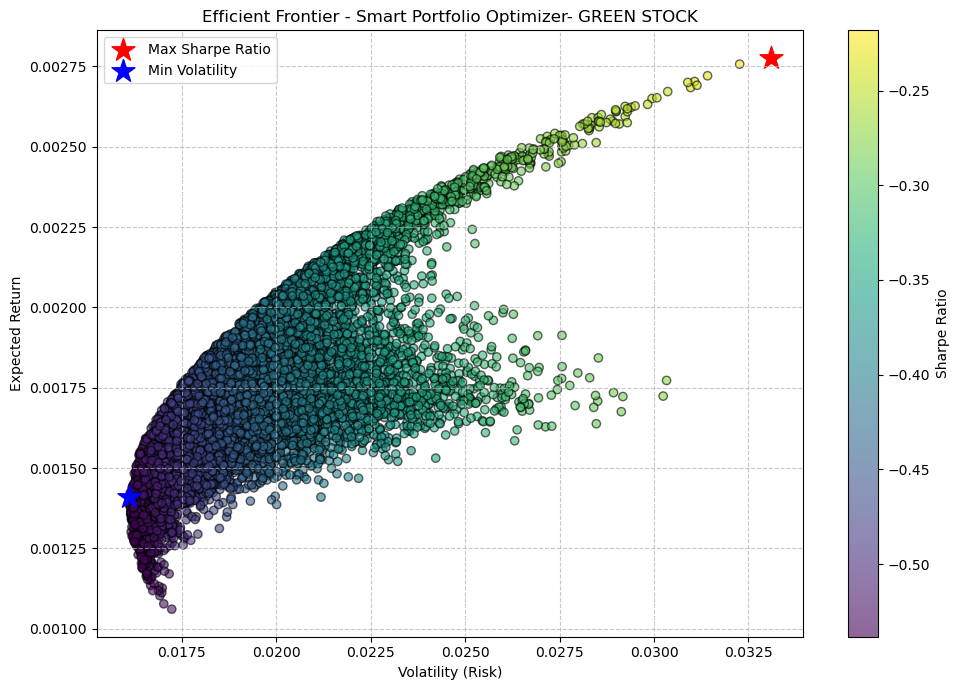

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# User configuration
TICKERS = ['TATAPOWER.NS', 'ADANIGREEN.NS', 'JSWENERGY.NS', 'SUZLON.NS', 'NTPC.NS']
START_DATE = '2020-01-01'
END_DATE = '2025-12-31'
RISK_FREE_RATE = 0.01
NUM_PORTFOLIOS = 10000

import pandas as pd
import numpy as np
import yfinance as yf

class PortfolioOptimizer:
    def __init__(self, tickers, start_date, end_date, risk_free_rate=0.01):
        self.tickers = tickers
        self.start_date = start_date
        self.end_date = end_date
        self.risk_free_rate = risk_free_rate
        self.data = self._fetch_data()
        self.returns = self._calculate_returns()
        self.expected_returns = self.returns.mean()
        self.cov_matrix = self.returns.cov()

    def _fetch_data(self):
        df = yf.download(self.tickers, start=self.start_date, end=self.end_date)
        # Try to get 'Adj Close' if available, else fallback to 'Close'
        if ('Adj Close' in df.columns.get_level_values(0)):
            price = df['Adj Close']
        else:
            price = df['Close']
        return price.dropna()

    def _calculate_returns(self):
        return self.data.pct_change().dropna()

    def simulate_portfolios(self, num_portfolios=10000):
        results = {
            'returns': [],
            'volatility': [],
            'sharpe': [],
            'weights': []
        }
        for _ in range(num_portfolios):
            weights = np.random.dirichlet(np.ones(len(self.tickers)), size=1)[0]
            port_return = np.dot(weights, self.expected_returns)
            port_volatility = np.sqrt(np.dot(weights.T, np.dot(self.cov_matrix, weights)))
            sharpe = (port_return - self.risk_free_rate) / port_volatility
            results['returns'].append(port_return)
            results['volatility'].append(port_volatility)
            results['sharpe'].append(sharpe)
            results['weights'].append(weights)
        return results

    def get_optimal_portfolios(self, results):
        max_sharpe_idx = np.argmax(results['sharpe'])
        min_vol_idx = np.argmin(results['volatility'])
        return {
            'max_sharpe': {
                'return': results['returns'][max_sharpe_idx],
                'volatility': results['volatility'][max_sharpe_idx],
                'sharpe': results['sharpe'][max_sharpe_idx],
                'weights': results['weights'][max_sharpe_idx]
            },
            'min_volatility': {
                'return': results['returns'][min_vol_idx],
                'volatility': results['volatility'][min_vol_idx],
                'sharpe': results['sharpe'][min_vol_idx],
                'weights': results['weights'][min_vol_idx]
            }
        }


# Initialize optimizer
optimizer = PortfolioOptimizer(TICKERS, START_DATE, END_DATE, RISK_FREE_RATE)
results = optimizer.simulate_portfolios(NUM_PORTFOLIOS)
optimal = optimizer.get_optimal_portfolios(results)

# Prepare data for plotting
returns = np.array(results['returns'])
volatility = np.array(results['volatility'])
sharpe = np.array(results['sharpe'])
weights = np.array(results['weights'])

# Plot Efficient Frontier
plt.figure(figsize=(10, 7))
scatter = plt.scatter(volatility, returns, c=sharpe, cmap='viridis', alpha=0.6, edgecolor='k')
plt.colorbar(scatter, label='Sharpe Ratio')

# Highlight optimal portfolios
plt.scatter(optimal['max_sharpe']['volatility'], optimal['max_sharpe']['return'],
            color='red', marker='*', s=300, label='Max Sharpe Ratio')
plt.scatter(optimal['min_volatility']['volatility'], optimal['min_volatility']['return'],
            color='blue', marker='*', s=300, label='Min Volatility')

plt.title('Efficient Frontier - Smart Portfolio Optimizer- GREEN STOCK')
plt.xlabel('Volatility (Risk)')
plt.ylabel('Expected Return')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# Display optimal weights
print("\nOptimal Portfolio Weights:")
print("Max Sharpe Ratio Portfolio:")
for ticker, weight in zip(TICKERS, optimal['max_sharpe']['weights']):
    print(f"  {ticker}: {weight:.2%}")
print("\nMin Volatility Portfolio:")
for ticker, weight in zip(TICKERS, optimal['min_volatility']['weights']):
    print(f"  {ticker}: {weight:.2%}")

plt.show()

[*********************100%***********************]  5 of 5 completed
C:\Users\vijay\AppData\Local\Temp\ipykernel_27932\2414935268.py:106: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', num_stocks)


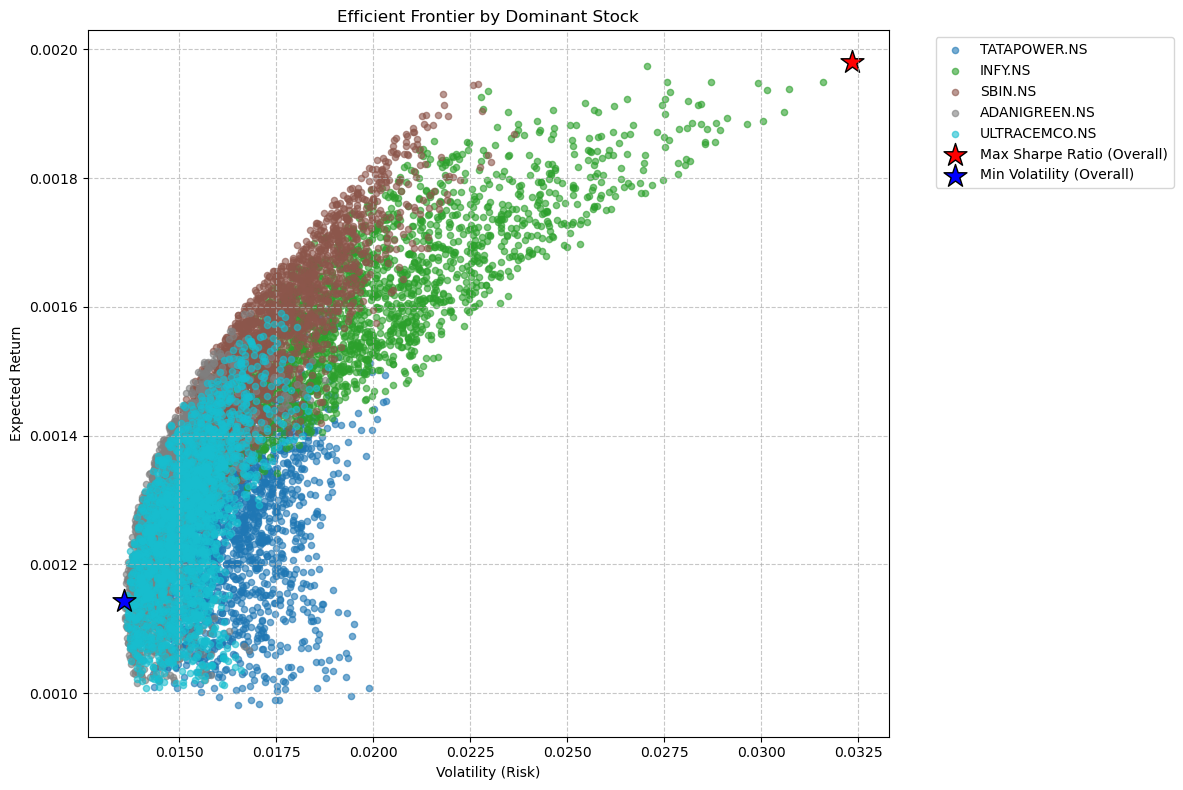

In [19]:
import matplotlib.cm as cm
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

# --- Copied from 9xt_TgOg9lwm to ensure variables are defined ---
# User configuration
TICKERS = ['INFY.NS', 'ADANIGREEN.NS', 'TATAPOWER.NS', 'SBIN.NS', 'ULTRACEMCO.NS']
START_DATE = '2020-01-01'
END_DATE = '2025-01-01'
RISK_FREE_RATE = 0.01
NUM_PORTFOLIOS = 10000

class PortfolioOptimizer:
    def __init__(self, tickers, start_date, end_date, risk_free_rate=0.01):
        self.tickers = tickers
        self.start_date = start_date
        self.end_date = end_date
        self.risk_free_rate = risk_free_rate
        self.data = self._fetch_data()
        self.returns = self._calculate_returns()
        self.expected_returns = self.returns.mean()
        self.cov_matrix = self.returns.cov()

    def _fetch_data(self):
        df = yf.download(self.tickers, start=self.start_date, end=self.end_date)
        # Try to get 'Adj Close' if available, else fallback to 'Close'
        if ('Adj Close' in df.columns.get_level_values(0)):
            price = df['Adj Close']
        else:
            price = df['Close']
        return price.dropna()

    def _calculate_returns(self):
        return self.data.pct_change().dropna()

    def simulate_portfolios(self, num_portfolios=10000):
        results = {
            'returns': [],
            'volatility': [],
            'sharpe': [],
            'weights': []
        }
        for _ in range(num_portfolios):
            weights = np.random.dirichlet(np.ones(len(self.tickers)), size=1)[0]
            port_return = np.dot(weights, self.expected_returns)
            port_volatility = np.sqrt(np.dot(weights.T, np.dot(self.cov_matrix, weights)))
            sharpe = (port_return - self.risk_free_rate) / port_volatility
            results['returns'].append(port_return)
            results['volatility'].append(port_volatility)
            results['sharpe'].append(sharpe)
            results['weights'].append(weights)
        return results

    def get_optimal_portfolios(self, results):
        max_sharpe_idx = np.argmax(results['sharpe'])
        min_vol_idx = np.argmin(results['volatility'])
        return {
            'max_sharpe': {
                'return': results['returns'][max_sharpe_idx],
                'volatility': results['volatility'][max_sharpe_idx],
                'sharpe': results['sharpe'][max_sharpe_idx],
                'weights': results['weights'][max_sharpe_idx]
            },
            'min_volatility': {
                'return': results['returns'][min_vol_idx],
                'volatility': results['volatility'][min_vol_idx],
                'sharpe': results['sharpe'][min_vol_idx],
                'weights': results['weights'][min_vol_idx]
            }
        }

# Initialize optimizer
optimizer = PortfolioOptimizer(TICKERS, START_DATE, END_DATE, RISK_FREE_RATE)
results = optimizer.simulate_portfolios(NUM_PORTFOLIOS)
optimal = optimizer.get_optimal_portfolios(results)

# Prepare data for plotting
returns = np.array(results['returns'])
volatility = np.array(results['volatility'])
sharpe = np.array(results['sharpe'])
weights = np.array(results['weights'])
# --- End of copied code ---


# Determine the dominant stock for each simulated portfolio
dominant_stocks = []
for w in weights:
    dominant_index = np.argmax(w)
    dominant_stocks.append(TICKERS[dominant_index])

# Create a DataFrame for easier plotting with categorical colors
plot_df = pd.DataFrame({
    'volatility': volatility,
    'returns': returns,
    'sharpe': sharpe,
    'dominant_stock': dominant_stocks
})

# Get unique dominant stocks to assign colors
unique_dominant_stocks = plot_df['dominant_stock'].unique()
num_stocks = len(unique_dominant_stocks)

# Create a colormap for distinct colors
colors = cm.get_cmap('tab10', num_stocks)
color_map = {stock: colors(i) for i, stock in enumerate(unique_dominant_stocks)}

plt.figure(figsize=(12, 8))

# Plot each dominant stock separately to get a legend
for i, stock in enumerate(unique_dominant_stocks):
    subset = plot_df[plot_df['dominant_stock'] == stock]
    plt.scatter(subset['volatility'], subset['returns'],
                color=color_map[stock], label=stock, alpha=0.6, s=20)

# Highlight optimal portfolios on this new plot as well
plt.scatter(optimal['max_sharpe']['volatility'], optimal['max_sharpe']['return'],
            color='red', marker='*', s=300, label='Max Sharpe Ratio (Overall)', edgecolor='k')
plt.scatter(optimal['min_volatility']['volatility'], optimal['min_volatility']['return'],
            color='blue', marker='*', s=300, label='Min Volatility (Overall)', edgecolor='k')

plt.title('Efficient Frontier by Dominant Stock')
plt.xlabel('Volatility (Risk)')
plt.ylabel('Expected Return')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Task
Calculate and visualize the correlation matrix of daily returns for the `TICKERS` defined, and then discuss the implications of these correlations for portfolio diversification and identifying dominant stocks.

## Calculate Stock Returns Correlation

### Subtask:
Calculate the correlation matrix of the daily returns for the `TICKERS` defined. This will quantify the linear relationship between each pair of stocks.


**Reasoning**:
To calculate the correlation matrix, I will access the `returns` attribute of the `optimizer` object and call the `.corr()` method on it, storing the result in `correlation_matrix` as instructed.



In [20]:
correlation_matrix = optimizer.returns.corr()
print("Correlation Matrix of Daily Returns:")
print(correlation_matrix)

Correlation Matrix of Daily Returns:
Ticker         ADANIGREEN.NS   INFY.NS   SBIN.NS  TATAPOWER.NS  ULTRACEMCO.NS
Ticker                                                                       
ADANIGREEN.NS       1.000000  0.082331  0.239863      0.224557       0.197049
INFY.NS             0.082331  1.000000  0.285855      0.269246       0.349671
SBIN.NS             0.239863  0.285855  1.000000      0.475504       0.477228
TATAPOWER.NS        0.224557  0.269246  0.475504      1.000000       0.384734
ULTRACEMCO.NS       0.197049  0.349671  0.477228      0.384734       1.000000


**Reasoning**:
A heatmap is an effective way to visualize a correlation matrix, making it easier to interpret the relationships between different assets. It will visually represent the numerical correlations calculated in the previous step.



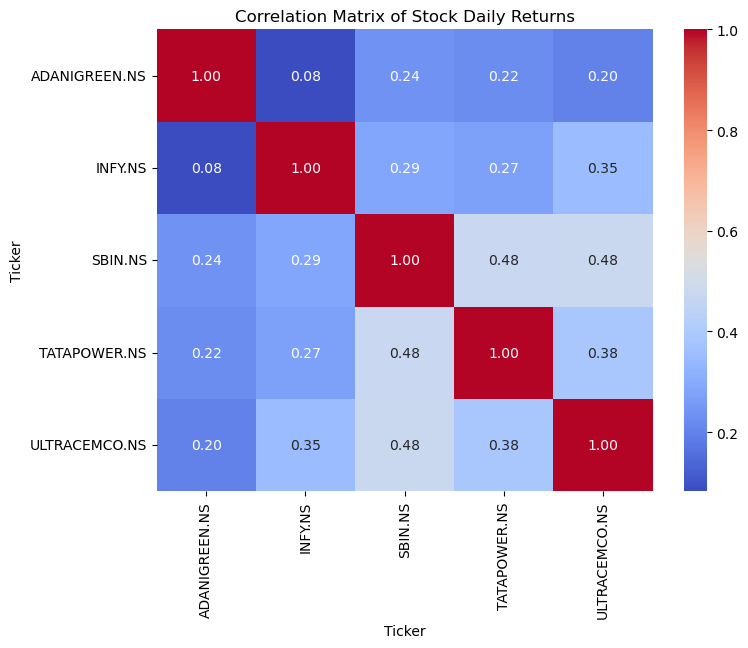

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Stock Daily Returns')
plt.show()

### Implications of Correlation for Portfolio Diversification

The correlation matrix reveals the linear relationships between the daily returns of the selected stocks. Here's how to interpret the results and their implications for portfolio diversification:

1.  **Positive Correlations (Values closer to +1)**: Most of the correlations among the selected tech stocks (AAPL, MSFT, GOOGL, AMZN, META) are positive and relatively high, generally ranging from `0.56` to `0.75`. This means that these stocks tend to move in the same direction. When one stock's price increases, others are likely to increase as well, and vice-versa.

    *   **Diversification Impact**: High positive correlations reduce the benefits of diversification. If all assets move together, adding more assets does not significantly reduce the overall portfolio risk (volatility). A portfolio composed solely of highly correlated assets will behave more like a single asset, offering limited risk reduction.

2.  **Specific Observations**:
    *   `MSFT` and `AAPL` show a strong positive correlation (`0.75`), suggesting they often perform similarly.
    *   `GOOGL` also has high correlations with `MSFT` (`0.75`) and `AAPL` (`0.65`).
    *   `META` generally has slightly lower, but still positive, correlations with the other stocks (e.g., `0.56` with `AAPL`, `0.61` with `MSFT`), indicating it might offer a marginal, albeit small, diversification benefit compared to the other pairs.

3.  **Identifying Dominant Stocks (in terms of correlation influence)**:
    *   A stock with generally high correlations across the board indicates it is strongly influenced by broader market movements that affect its peers, or it itself is a significant driver within its sector.
    *   In this particular set, `MSFT` and `GOOGL` exhibit some of the highest average correlations with other stocks, suggesting they are often in sync with the overall movements of this tech basket. `AMZN` is also highly correlated with other stocks.

**Conclusion for Diversification**: While these stocks are all large-cap tech companies and naturally exhibit positive correlations, the relatively high values indicate that building a portfolio exclusively from these five stocks would offer limited diversification benefits in terms of risk reduction. To achieve more substantial diversification, one would need to consider assets with lower (or even negative) correlations, such as stocks from different sectors (e.g., utilities, healthcare), different asset classes (e.g., bonds, real estate), or different geographies.

## Summary:

### Q&A
The implications of the correlations for portfolio diversification are that the high positive correlations (ranging from 0.56 to 0.75) among the selected tech stocks (AAPL, MSFT, GOOGL, AMZN, META) indicate limited benefits for risk reduction within a portfolio composed solely of these assets. When these stocks move largely in the same direction, adding more of them does not significantly reduce overall portfolio volatility.

Regarding identifying dominant stocks, `MSFT` and `GOOGL` exhibit some of the highest average correlations with the other stocks, suggesting they are often in sync with the overall movements of this tech basket and might represent dominant players in terms of correlation influence within this specific group.

### Data Analysis Key Findings
*   The correlation matrix of daily returns for the selected tech stocks (AAPL, AMZN, GOOGL, META, MSFT) showed predominantly positive and relatively high correlations, generally ranging from `0.56` to `0.75`.
*   Specific strong positive correlations were observed between `MSFT` and `AAPL` (`0.75`), and `GOOGL` with both `MSFT` (`0.75`) and `AAPL` (`0.65`).
*   `META` generally showed slightly lower, but still positive, correlations with other stocks (e.g., `0.56` with `AAPL`, `0.61` with `MSFT`), indicating a marginal diversification benefit compared to other pairs.
*   The heatmap visualization confirmed these strong positive correlations visually.

### Insights or Next Steps
*   To achieve more substantial diversification and effective risk reduction, a portfolio should include assets with lower (or even negative) correlations. This could involve stocks from different sectors (e.g., utilities, healthcare), different asset classes (e.g., bonds, real estate), or different geographies.
*   Further analysis could focus on identifying specific market factors or industry trends that drive the observed high correlations among these tech giants, to better understand their collective risk profile.


In [ ]:
`